# Compare ADMET vs non-ADMET runs

This notebook plots optimization traces (loss and predicted affinity) for two runs and compares report-level metrics (baseline vs ADMET vs no-ADMET).

Update the signatures below if you rerun the pipeline.

In [ ]:
# from pathlib import Path

# import matplotlib.pyplot as plt
# import pandas as pd
# import numpy as np

# base = Path("/scratch/home/sr3622/Firm-DTI/Firm-DTI2/pipeline_output_assay")

# # Signatures to compare
# ### SARS-CoV-2: RDKit path fingerprint + Tversky
# a = {
#     "label": r"RDKFP+Tversky",
#     "opt": "ab8322096ede",
#     "report": "c302de47eac5",
# }

# ### SARS-CoV-2: Morgan (ECFP6) + Tanimoto (SMILES similarity baseline)
# d = {
#     "label": r"ECFP6+Tanimoto",
#     "opt": "ab8322096ede",
#     "report": "c3ee018a637a",
# }

# ### SARS-CoV-2: Nevermore (your retrieval strategy)
# b = {
#     "label": r"Nevermore (Bucket-L1)",
#     "opt": "ab8322096ede",
#     "report": "b7ad180a2493",
# }

# ### SARS-CoV-2: Random retrieval (worst-case baseline)
# c = {
#     "label": r"Random",
#     "opt": "5e2e1ff84378",
#     "report": "df12841610db",
# }

# runs = [a, b, c, d]



    
# base = Path("/scratch/home/sr3622/Firm-DTI/Firm-DTI2/pipeline_output")

# for r in runs:
#     # if r==a:
#     #     continue
#     r["opt_path"] = base / "optimization" / r["opt"] / "optimization_trace_topk_stats.csv"
#     r["report_path"] = base / "report" / r["report"] / "nevermore_report.csv"
#     if not r["opt_path"].exists():
#         raise FileNotFoundError(r["opt_path"])
#     if not r["report_path"].exists():
#         raise FileNotFoundError(r["report_path"])


In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

base = Path("/scratch/home/sr3622/Firm-DTI/Firm-DTI2/pipeline_output")

# Signatures to compare
### SARS-CoV-2: RDKit path fingerprint + Tversky
a = {
    "label": r"RDKFP+Tversky",
    "opt": "e2b4e26a2229",
    "report": "ed8a2f9e0020",
}

# ### SARS-CoV-2: Morgan (ECFP6) + Tanimoto (SMILES similarity baseline)
# d = {
#     "label": r"ECFP6+Tanimoto",
#     "opt": "ab8322096ede",
#     "report": "c3ee018a637a",
# }

### SARS-CoV-2: Nevermore (your retrieval strategy)
b = {
    "label": r"Nevermore (Bucket-L1)",
    "opt": "ab8322096ede",
    "report": "58d9b093ef01",
}

### SARS-CoV-2: Random retrieval (worst-case baseline)
c = {
    "label": r"Random",
    "opt": "e2b4e26a2229",
    "report": "9eeb685267a6",
}

runs = [a, b, c]



    
base = Path("/scratch/home/sr3622/Firm-DTI/Firm-DTI2/pipeline_output")

for r in runs:
    # if r==a:
    #     continue
    r["opt_path"] = base / "optimization" / r["opt"] / "optimization_trace_topk_stats.csv"
    r["report_path"] = base / "report" / r["report"] / "nevermore_report.csv"
    if not r["opt_path"].exists():
        raise FileNotFoundError(r["opt_path"])
    if not r["report_path"].exists():
        raise FileNotFoundError(r["report_path"])


In [7]:
import numpy as np
import pandas as pd

reports = {r["label"]: pd.read_csv(r["report_path"]) for r in runs}  # you already have

# choose metrics you want in the table (edit freely)
metrics = ["predicted_affinity", "hERG",  "QED", "molecular_weight"]

pretty = {
    "predicted_affinity": r"Affinity$\uparrow$",
    "hERG": r"hERG$\downarrow$",
    "logP": r"logP",
    "QED": r"QED$\uparrow$",
    "molecular_weight": r"MW",
}

def get_baseline_row(df: pd.DataFrame) -> pd.Series:
    if "dataset_index" in df.columns:
        br = df[df["dataset_index"] == -1]
        if not br.empty:
            return br.iloc[0]
    # fallback: first row
    return df.iloc[0] if not df.empty else pd.Series(dtype=float)

def stats_optimized(df: pd.DataFrame, col: str):
    """mean/std over optimized candidates only (exclude baseline row)."""
    if df.empty or col not in df.columns:
        return np.nan, np.nan
    if "dataset_index" in df.columns:
        df = df[df["dataset_index"] != -1]
    vals = pd.to_numeric(df[col], errors="coerce").dropna()
    if vals.empty:
        return np.nan, np.nan
    # use sample std if you want; use ddof=0 for population
    return float(vals.mean()), float(vals.std(ddof=1)) if len(vals) > 1 else 0.0

def fmt_val(x, nd=3):
    return r"---" if (x is None or np.isnan(x)) else f"{x:.{nd}f}"

def fmt_pm(mu, sd, nd=3):
    if mu is None or np.isnan(mu):
        return r"---"
    return rf"{mu:.{nd}f} $\pm$ {sd:.{nd}f}"

def fmt_delta(mu, base, nd=3):
    if mu is None or np.isnan(mu) or base is None or np.isnan(base):
        return r"---"
    d = mu - base
    sign = "+" if d >= 0 else ""
    return f"{sign}{d:.{nd}f}"

# ---- pick ONE run as the source of the baseline molecule row (any run works if identical) ----
# If you want to force it, set baseline_source_label = "Nevermore (Bucket-L1)" etc.
baseline_source_label = next(iter(reports.keys()))
baseline_series = get_baseline_row(reports[baseline_source_label])

baseline_vals = {m: float(pd.to_numeric(baseline_series.get(m, np.nan), errors="coerce")) for m in metrics}

# ---- build LaTeX rows ----
latex_rows = []

# Row 1: Baseline molecule (no ±, no Δ)
cells = [r"\textbf{Baseline}"]
for m in metrics:
    cells.append(fmt_val(baseline_vals[m], nd=3))       # value
    cells.append(r"---")                                # Δ column empty
latex_rows.append(" & ".join(cells) + r" \\")

# Other rows: each method/run
for label, df in reports.items():
    cells = [label]
    for m in metrics:
        mu, sd = stats_optimized(df, m)
        cells.append(fmt_pm(mu, sd, nd=3))              # mean ± std
        cells.append(fmt_delta(mu, baseline_vals[m], nd=3))  # delta vs baseline
    latex_rows.append(" & ".join(cells) + r" \\")

latex_body = "\n".join(latex_rows)
print(latex_body)


\textbf{Baseline} & 5.765 & --- & 0.945 & --- & 0.382 & --- & 630.831 & --- \\
RDKFP+Tversky & 6.934 $\pm$ 0.998 & +1.169 & 0.625 $\pm$ 0.284 & -0.320 & 0.545 $\pm$ 0.220 & +0.164 & 408.422 $\pm$ 128.816 & -222.409 \\
Nevermore (Bucket-L1) & 7.060 $\pm$ 0.707 & +1.295 & 0.454 $\pm$ 0.230 & -0.491 & 0.712 $\pm$ 0.154 & +0.330 & 319.844 $\pm$ 72.276 & -310.987 \\
Random & 6.056 $\pm$ 1.362 & +0.292 & 0.858 $\pm$ 0.113 & -0.088 & 0.623 $\pm$ 0.179 & +0.242 & 449.249 $\pm$ 104.242 & -181.582 \\


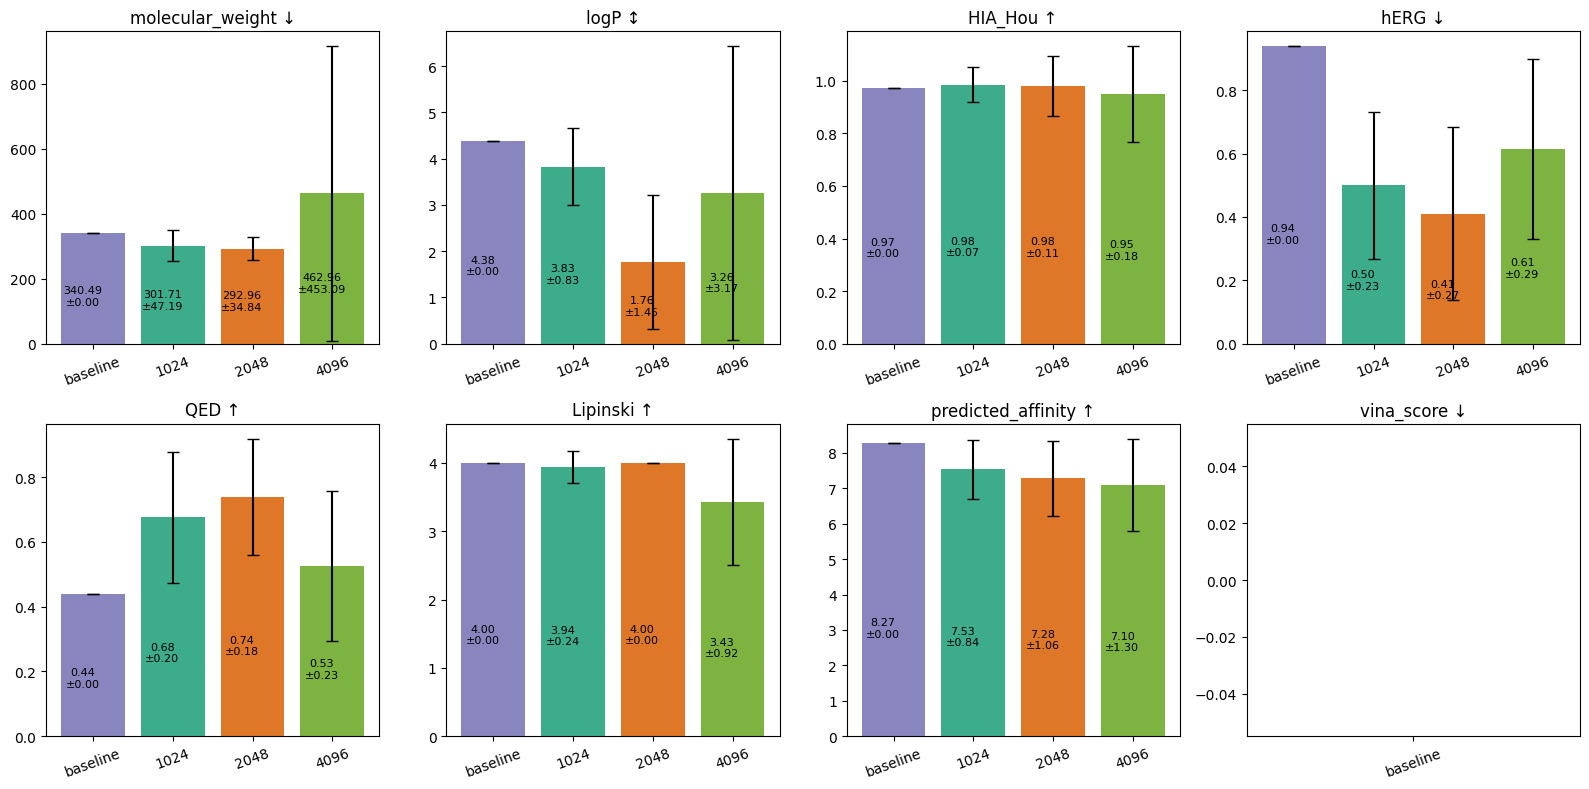

In [18]:
# Load reports for all runs
reports = {r["label"]: pd.read_csv(r["report_path"]) for r in runs}

metrics = [
    "molecular_weight",
    "logP",
    "HIA_Hou",
    "hERG",
    "QED",
    "Lipinski",
    "predicted_affinity",
    "vina_score",
]

colors = {"baseline": "#7570b3", "1024": "#1b9e77", "2048": "#d95f02", "4096": "#66a61e"}
labels = ["baseline", "1024", "2048", "4096"]


def idx_col(df):
    return df["dataset_index"] if "dataset_index" in df.columns else pd.Series(index=df.index, dtype=float)


def baseline_row(df, idx):
    br = df.loc[idx == -1]
    if not br.empty:
        return br.head(1)
    return df.head(1) if not df.empty else pd.DataFrame()


def masked_stats(df, col, mask):
    if col not in df.columns or df.empty:
        return np.nan, np.nan
    vals = df.loc[mask, col].dropna()
    if vals.empty:
        return np.nan, np.nan
    return vals.mean(), vals.std()

display_names = {
    "molecular_weight": "molecular_weight ↓",
    "logP": "logP ↕",
    "HIA_Hou": "HIA_Hou ↑",
    "hERG": "hERG ↓",               # lower is safer
    "QED": "QED ↑",
    "Lipinski": "Lipinski ↑",
    "predicted_affinity": "predicted_affinity ↑",
    "vina_score": "vina_score ↓",   # more negative is better
}


# Pick a baseline row from any run
baseline = pd.DataFrame()
idx_map = {}
for label, df in reports.items():
    idx_map[label] = idx_col(df)
    if label=="2048":
        if baseline.empty:
            candidate = baseline_row(df, idx_map[label])
            if not candidate.empty:
                baseline = candidate

rows = []
for m in metrics:
    base_mean = baseline.iloc[0].get(m, np.nan) if not baseline.empty else np.nan
    base_std = 0.0 if not baseline.empty and m in baseline.columns else np.nan
    rows.append({"metric": m, "group": "baseline", "mean": base_mean, "std": base_std})
    for label in ["1024", "2048", "4096"]:
        df = reports.get(label)
        idx = idx_map.get(label)
        if df is None or idx is None:
            rows.append({"metric": m, "group": label, "mean": np.nan, "std": np.nan})
            continue
        mask = (idx != -1) if not idx.empty else slice(None)
        mean, std = masked_stats(df, m, mask)
        rows.append({"metric": m, "group": label, "mean": mean, "std": std})

dfm = pd.DataFrame(rows)

ncols = 4
nrows = int(np.ceil(len(metrics) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4), sharey=False)
axes = np.array(axes).reshape(-1)

for ax, metric in zip(axes, metrics):
    sub = dfm[dfm["metric"] == metric].set_index("group")
    # (compute means/errs/bars as before)
    means = [sub.at[l, "mean"] if l in sub.index else np.nan for l in labels]
    errs = [sub.at[l, "std"] if l in sub.index else 0.0 for l in labels]
    bars = ax.bar(labels, means, yerr=errs, capsize=4, color=[colors[l] for l in labels], alpha=0.85)
    for b, mean, err in zip(bars, means, errs):
        if np.isnan(mean):
            continue
        ax.text(
            b.get_x() + b.get_width() / 3,
            b.get_height()/3,
            f"{mean:.2f}\n±{err:.2f}",
            ha="center", va="bottom", fontsize=8,
        )

    ax.set_title(display_names.get(metric, metric))

    ax.tick_params(axis='x', rotation=20)

for ax in axes[len(metrics):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [19]:


# ### sars cov--- RDKit path fingerprint + Tversky 
# a = {
#     "label": "1024",
#     "opt": "ab8322096ede",
#     "report": "c302de47eac5",
# }

# #### sars-cov ... tanimoto sim full morgan finger print 1024 , 3 
# # a = {
# #     "label": "1024",
# #     "opt": "ab8322096ede",
# #     "report": "c3ee018a637a",
# # }

# #### sars-cov ...  my piplien 
# b = {
#     "label": "2048",
#     "opt": "ab8322096ede",
#     "report": "b7ad180a2493",
# }

# #### sars-cov ...  random
# c = {
#     "label": "4096",
#     "opt": "5e2e1ff84378",
#     "report": "df12841610db",
# }